In [93]:
from astropy import units as u
from astropy import time
import astropy
import numpy as np

from poliastro import iod
from poliastro.bodies import Body,Mars, Earth, Venus, Jupiter, Saturn, Uranus, Neptune, Sun, Europa, Ganymede, Callisto, Io, Titan
from poliastro.ephem import Ephem
from poliastro.maneuver import Maneuver
from poliastro.twobody import Orbit
from poliastro.util import time_range
from poliastro.frames import Planes
from poliastro.frames.fixed import JupiterFixed
from poliastro.frames.equatorial import JupiterICRS
from astroquery.jplhorizons import Horizons
from copy import deepcopy

from scipy import ndimage
from scipy.spatial.transform import Rotation as scipyRot
from collections import defaultdict
from poliastro.plotting import OrbitPlotter3D, StaticOrbitPlotter
import math
import matplotlib.pyplot as plt
# More info: https://plotly.com/python/renderers/
import plotly.io as pio
from poliastro.util import norm, time_range
pio.renderers.default = "plotly_mimetype+notebook_connected"
import weakref
from astropy.coordinates import solar_system_ephemeris
from collections.abc import Mapping
from poliastro.extra_util import get_galilean_orbs, ecliptic_slingshot, get_galilean_ephemerides, slingshot_to_another_body
# from poliastro.extra_util import *
solar_system_ephemeris.set("jpl")

from libs import jovian_spenvis_model

In [94]:
def dose_rate(r): 
    a=2
    return 1

def tid_for_orbit(orbit,start,end,step=0.1*u.day):
    cum_tid=0
    test_orb=orbit.propagate(start)
    for t in time_range(start,end,step):
        test_orb=orb.propagate(t)
        cum_tid+=dose_rate(np.linalg.norm(test_orb.r))*step
    return cum_tid
    

In [95]:
##Incriments spacecraft by tof_step forward and scans over all allowed tofs

def get_single_burn_elliptical_hohmann_brute_force(target_orb, initial_orb,min_departure_wait=0*u.day,max_depature_wait=50*u.day, min_tof=0.1*u.day, max_tof=50*u.day, tof_step=0.1*u.day, retrograde_only=False,fine_scan=False,max_encounter_v=20*u.km/u.s):
    min_dv=50000*u.m/u.s
    start_epoch=initial_orb.epoch
    final_orb=None
    final_date=None
    final_burn_date=None
    final_targ_orb=None
    final_tof=None
    departure_date_range=np.arange(min_departure_wait.to(u.day).value,max_depature_wait.to(u.day).value,tof_step.to(u.day).value)*u.day
    tof_range=np.arange(min_tof.to(u.day).value,max_tof.to(u.day).value,tof_step.to(u.day).value)*u.day
    for d in departure_date_range:
        pre_burn_orbit=initial_orb.propagate(d)
        for i in range(len(tof_range)):
            arrival_date=start_epoch+d+tof_range[i]
            body_orb=target_orb.propagate(arrival_date+1*u.s)
            #try multiple revolutions of lambert arcs
            for j in range(0,3):
                try:
                    lambert=Maneuver.lambert(pre_burn_orbit,body_orb,M=j)
                    burn=lambert[0]
                    dv=np.linalg.norm(burn[1])
                    #check for max encounter velocity
                    try_orb, dummy = pre_burn_orbit.apply_maneuver(lambert, intermediate=True)
                    encounter_v = norm(try_orb.propagate(arrival_date).v - body_orb.v).to(u.km/u.s)
                    if encounter_v>max_encounter_v:
                        continue
                    #check for retrograde if needed
                    progradeness=np.dot(burn[1].to(u.km/u.s).value,body_orb.v.to(u.km/u.s).value)
                    if retrograde_only and (progradeness)<0:
                        continue
                
                    if dv<min_dv:
                        min_dv=dv
                        final_orb,dummy=pre_burn_orbit.apply_maneuver(lambert,intermediate=True)
                        final_date=arrival_date
                        final_burn_date=d
                        final_targ_orb=body_orb
                        final_tof=tof_range[i]
                        # plotter.plot(final_orb)
                except Exception as e:
                    # print(e)
                    continue
    results=[min_dv,final_orb,final_targ_orb,final_date,final_burn_date]
    print("Best dv:", min_dv)
    if not fine_scan:
        print(f"Refining search around burn at {final_burn_date:.1f} with {final_tof:.1f} transfer time.")
        test_min_tof=final_tof-5*tof_step
        test_max_tof=final_tof+5*tof_step
        test_max_depature_wait=final_burn_date
        transfer=get_single_burn_elliptical_hohmann_brute_force(
            target_orb,
            initial_orb,
            min_departure_wait=test_max_depature_wait-5*tof_step,
            max_depature_wait=test_max_depature_wait+tof_step*5,
            min_tof=test_min_tof,
            max_tof=test_max_tof,
            tof_step=tof_step/10,
            retrograde_only=retrograde_only,
            fine_scan=True,
            max_encounter_v=max_encounter_v          
        )
        results=transfer
    return results

In [96]:

start_date= time.Time("2037-08-06 00:01", scale="utc").tdb
end_date= time.Time("2037-12-21 00:01", scale="utc").tdb
epochs=time_range(start=start_date,end=end_date,periods=50)

callisto_ephem = Ephem.from_horizons(504,epochs= epochs, attractor= Jupiter,plane=Planes.EARTH_ECLIPTIC)#Callisto is 504
callisto_orb= Orbit.from_ephem(attractor=Jupiter,ephem=callisto_ephem,epoch=start_date)
ephemerides = get_galilean_ephemerides(start_date, end_date)


# # Access like this:
europa_ephem = ephemerides[Europa]
io_ephem = ephemerides[Io]
ganymede_ephem = ephemerides[Ganymede]
callisto_ephem = ephemerides[Callisto]
galilean_orbs = get_galilean_orbs(start_date,start_date+10*u.day)

# Access like this:
europa_orb = galilean_orbs[Europa]
print(europa_orb)
europa_orb= Orbit.from_ephem(attractor=Jupiter,ephem=europa_ephem,epoch=start_date)
ganymede_orb= Orbit.from_ephem(attractor=Jupiter,ephem=ganymede_ephem,epoch=start_date)
io_orb= galilean_orbs[Io]
callisto_orb= Orbit.from_ephem(attractor=Jupiter,ephem=callisto_ephem,epoch=start_date)

r_perijove = 1.05*Jupiter.R 
r_apijove = 165*Jupiter.R
a_start = (r_perijove+r_apijove)/2
ecc_start = (r_perijove-r_apijove)/(r_perijove+r_apijove)

starship_orb=Orbit.from_classical(
Jupiter, a_start, ecc_start, io_orb.inc, 
io_orb.raan, 0*u.deg, -2*u.deg,
start_date+20*u.day,plane=Planes.EARTH_ECLIPTIC)


print(starship_orb.period.to(u.day))

#List will store all orbits
all_orbits=[]



/home/jack/Documents/miniforge3-n/envs/cleanastronomy/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning:

ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"

/home/jack/Documents/miniforge3-n/envs/cleanastronomy/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning:

ERFA function "utctai" yielded 1 of "dubious year (Note 3)"

/home/jack/Documents/miniforge3-n/envs/cleanastronomy/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning:

ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"



665082 x 677012 km x 2.1 deg orbit around Jupiter (♃) at epoch 2037-08-06 00:02:09.183 (TDB)
93.4233513755375 d


In [97]:
post_joi_orb_for_rad=Orbit.from_classical(
Jupiter, a_start, ecc_start, io_orb.inc, 
io_orb.raan, 0*u.deg, -179*u.deg,
start_date-20*u.day,plane=Planes.EARTH_ECLIPTIC)

all_orbits.insert(0,post_joi_orb_for_rad)

In [98]:
print((r_apijove/Jupiter.R.to(u.km)).to(u.one))
print((r_perijove/Jupiter.R.to(u.km)).to(u.one))

165.0
1.05


In [99]:
#Raise apijove to encounter Ganymede
transfer_to_io=get_single_burn_elliptical_hohmann_brute_force(
    ganymede_orb,
    starship_orb,
    max_depature_wait=5*u.day,
    tof_step=0.5*u.day,
    min_tof=10*u.day,
    max_tof=65*u.day,
    retrograde_only=False,
    max_encounter_v=10.0*u.km/u.s
)

Best dv: 650.6737906426254 m / s
Refining search around burn at 4.5 d with 60.0 d transfer time.
Best dv: 622.0646695661433 m / s


In [100]:
def rotate_plot_90(ax, ccw=True):
    # 90° rotation: CCW (x,y)->(-y,x), CW (x,y)->(y,-x)
    for line in ax.lines:
        x, y = line.get_data()
        x = np.asarray(x); y = np.asarray(y)
        if ccw:
            line.set_data(-y, x)
        else:
            line.set_data(y, -x)

    # scatter/path collections (often used for points)
    for col in ax.collections:
        if hasattr(col, "get_offsets"):
            off = np.asarray(col.get_offsets())
            if off.size and off.shape[1] >= 2:
                x = off[:, 0]; y = off[:, 1]
                new_off = np.column_stack((-y, x)) if ccw else np.column_stack((y, -x))
                col.set_offsets(new_off)

    # patches (often circles for bodies)
    for p in ax.patches:
        if hasattr(p, "center"):
            x, y = p.center
            p.center = (-y, x) if ccw else (y, -x)

    ax.set_aspect("equal", adjustable="box")
    ax.relim()
    ax.autoscale_view()


/home/jack/Documents/miniforge3-n/envs/cleanastronomy/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning:

ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"

/home/jack/Documents/miniforge3-n/envs/cleanastronomy/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning:

ERFA function "utctai" yielded 1 of "dubious year (Note 3)"

/home/jack/Documents/miniforge3-n/envs/cleanastronomy/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning:

ERFA function "taiutc" yielded 150 of "dubious year (Note 4)"



Arrival on Io at 2037-10-29 13:14:09.183


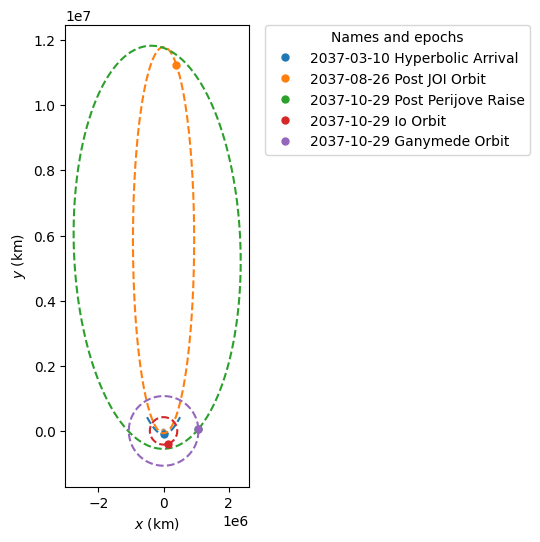

Initial orbit has ecc of 1.047393237114361
Capture into 11796180 x 75067 km x 2.2 deg orbit around Jupiter (♃) at epoch 2037-08-26 00:02:09.183 (TDB)
Initial orbital period is 93.4233513755375 d
Burn to reach Ganymede with 554270 x 11840542 km x 2.3 deg orbit around Jupiter (♃) at epoch 2037-09-01 22:50:09.183 (TDB)
Distance from Ganymede should be 1037962.78 km


In [101]:
#C3 only orbit calc
c3_a=56*(u.km**2)/(u.s**2)
r_p = Jupiter.R*0.5#arrival periapsis
a_exit = -(Jupiter.k / c3_a).to(u.km)
ecc_exit = 1 - (r_p+Jupiter.R) / a_exit

arrival_orbit = Orbit.from_classical(
    Jupiter,
    a_exit,
    ecc_exit,
    0 * u.deg,
    starship_orb.raan,
    starship_orb.argp+180*u.degree,
    0 * u.deg,  # We don't mind
    time.Time("2037-03-10 00:01", scale="utc"),
    plane=Planes.EARTH_ECLIPTIC
)
plotter=StaticOrbitPlotter(plane=Planes.EARTH_ECLIPTIC)
io_arrival_date_1=transfer_to_io[3]
# plotter.plot(callisto_orb, label="Callisto Orbit")
plotter.plot(arrival_orbit,label='Hyperbolic Arrival')

plotter.plot(starship_orb.propagate(0*u.day), label="Post JOI Orbit")
plotter.plot(transfer_to_io[1].propagate(io_arrival_date_1), label="Post Perijove Raise")

plotter.plot(io_orb.propagate(io_arrival_date_1), label="Io Orbit")
plotter.plot(ganymede_orb.propagate(io_arrival_date_1), label="Ganymede Orbit")
print(f"Arrival on Io at {transfer_to_io[3]}")
pre_io_starship_flyby=transfer_to_io[1].propagate(io_arrival_date_1)

# Get the matplotlib Axes (poliastro versions differ: ax vs _ax)
ax = getattr(plotter, "ax", None) or plotter._ax

# Example: zoom to a +/- 5e8 km box around (0,0)
# range=5e9
# ax.set_xlim(-range, range)
# ax.set_ylim(-range, range)
ax.set_aspect("equal", adjustable="box")
rotate_plot_90(ax, ccw=False)   # 90° counter-clockwise
plt.show()
print(f"Initial orbit has ecc of {arrival_orbit.ecc}")
print(f"Capture into {starship_orb}")
print(f"Initial orbital period is {starship_orb.period.to(u.day)}")
print(f"Burn to reach Ganymede with {transfer_to_io[1]}")

all_orbits.append(starship_orb)
all_orbits.append(transfer_to_io[1])

print(f"Distance from Ganymede should be {np.linalg.norm(pre_io_starship_flyby.r-io_orb.propagate(io_arrival_date_1).r):.2f}")

In [102]:
def ecliptic_slingshot_dummy(spacecraft_orb,body_orb,body,h_p,sign):
    r_p=h_p+body.R
    attractor=spacecraft_orb.attractor
    flyby_dist=np.linalg.norm(spacecraft_orb.r-body_orb.r)
    if(flyby_dist)<4*body.R:
        rel_vel=spacecraft_orb.rv()[1]-body_orb.rv()[1]
        rel_speed=np.linalg.norm(rel_vel)
        rot_ang = 2 * np.arcsin(1 / ((r_p * rel_speed**2 / body.k) + 1 * u.one))
        if(r_p<body.R):
            print("Warning: spacecraft crashes into the body, ignoring that for now.")
        # Rotation axis in ecliptic plane
        axis = np.array([0, 0, 1.0])
        axis = axis / np.linalg.norm(axis)
        # Rotate the relative velocity
        rot = scipyRot.from_rotvec(sign * axis * rot_ang.value)
        rel_vel_out = rot.apply(rel_vel.value) * u.km / u.s
        
        # Calculate post-assist velocity in attractor frame
        post_assist_vel = rel_vel_out + body_orb.rv()[1]
        
        # Create orbit from post-assist state
        test_orb = Orbit.from_vectors(
            attractor, 
            body_orb.r, 
            post_assist_vel, 
            spacecraft_orb.epoch,
            plane=Planes.EARTH_ECLIPTIC
        )

        return (post_assist_vel,test_orb)
                
                
    else:
        print(f"Trajectory does not fly past {body} closely enough - misses by {flyby_dist.to(u.km):.1f}")
        return None

In [103]:
def assist_possible_periods(spacecraft_orb, body_orb, body, r_p_min=10*u.km, r_p_max=5000*u.km, num_samples=500):#finds possible periods of orbit around attractor given flyby
    periods=np.zeros((num_samples,2))
    periaps=np.zeros((num_samples))
    attractor=spacecraft_orb.attractor
    flyby_dist=np.linalg.norm(spacecraft_orb.r-body_orb.r)
    if(flyby_dist)<4*body.R:
        rel_vel=spacecraft_orb.rv()[1]-body_orb.rv()[1]
        rel_speed=np.linalg.norm(rel_vel)
        r_ps = body.R + np.linspace(r_p_min.to(u.km).value, r_p_max.to(u.km).value, num=num_samples) * u.km
        rot_angs = 2 * np.arcsin(1 / ((r_ps * rel_speed**2 / body.k) + 1 * u.one))
        # Rotation axis in ecliptic plane
        axis = np.array([0, 0, 1.0])
        axis = axis / np.linalg.norm(axis)
        # Try both rotation directions (leading/trailing side flybys)
        for j,sign in enumerate([1,-1]):
            for i, rot_ang in enumerate(rot_angs):
                # Rotate the relative velocity
                rot = scipyRot.from_rotvec(sign * axis * rot_ang.value)
                rel_vel_out = rot.apply(rel_vel.value) * u.km / u.s
                
                # Calculate post-assist velocity in attractor frame
                post_assist_vel = rel_vel_out + body_orb.rv()[1]
                
                # Create orbit from post-assist state
                test_orb = Orbit.from_vectors(
                    attractor, 
                    body_orb.r, 
                    post_assist_vel, 
                    spacecraft_orb.epoch,
                    plane=Planes.EARTH_ECLIPTIC
                )
                periods[i][j]=test_orb.period.to(u.day).value
                periaps[i]=r_ps[i].to(u.km).value
        return (periods,periaps)
                
                
    else:
        print(f"Trajectory does not fly past {body} closely enough - misses by {flyby_dist.to(u.km):.1f}")
        return None

def resonance_search(spacecraft_orb,body,r_p_min=10*u.km, r_p_max=5000*u.km, lower=True, numerator_prioritize=True, max_numerator=9,sim_start_date=time.Time("2037-03-10 00:01", scale="utc").tdb):
    used_orbit=deepcopy(spacecraft_orb)
    attractor=spacecraft_orb.attractor
    galilean_orbs=get_galilean_orbs(sim_start_date,sim_start_date+10*u.day)
    prelim_body_orb= galilean_orbs[body].propagate(used_orbit.epoch)
    postflyby_data=assist_possible_periods(used_orbit, prelim_body_orb, body,r_p_min=r_p_min, r_p_max=r_p_max,num_samples=5000)
    possible_resonances=[]
    if postflyby_data is not None:
        ##Check which side gives lower periods
        trailing_mean_period = np.mean(postflyby_data[:][0])
        leading_mean_period = np.mean(postflyby_data[0][:, 1])
        if trailing_mean_period < leading_mean_period:
            lower_side = 0  # Trailing side (sign=1)
            # print("Trailing side flybys give lower periods")
        else:
            lower_side = 1  # Leading side (sign=-1)
            # print("Leading side flybys give lower periods")

        side=lower_side if lower else 1-lower_side

        sign=int((-1)**(side))

        
        #generate allowed resonances      
        pairs = np.array([(i, j)
                  for i in range(1, max_numerator + 1)
                  for j in range(1, max_numerator + 1)
                  if math.gcd(i, j) == 1], dtype=int)
        # optional: the fraction values
        vals = pairs[:, 0] / pairs[:, 1]
        # print(vals)
        possible_resonant_periods = vals*prelim_body_orb.period.to(u.day)
        for i,period in enumerate(postflyby_data[0][:,side]):
            for j,test_period in enumerate(possible_resonant_periods):
                t_ratio=(((period*u.day)/test_period).to(u.one)).value
                if abs(1-t_ratio)<0.001:
                    # print(f"At {test_period:.1f} ie {pairs[j]} with flyby at {postflyby_data[1][i]*u.km-body.R.to(u.km)}")
                    possible_resonances.append((pairs[j], postflyby_data[1][i]*u.km-body.R.to(u.km)))
        # print(possible_resonances)
        
        groups = defaultdict(list)

        for frac_arr, rp in possible_resonances:
            key = tuple(frac_arr.tolist())      # e.g. (5, 7)
            groups[key].append(rp.to(u.km))     # keep as Quantity
        # one averaged periapsis per resonance fraction
        averaged = []
        for key, rps in groups.items():
            rp_mean = np.mean(u.Quantity(rps))  # Quantity mean, stays in km
            averaged.append((np.array(key, dtype=int), rp_mean, len(rps)))         
        if numerator_prioritize:#pick the resonance with the lowest numerator
            averaged.sort(key=lambda x: (x[0][0], x[1].value))  # Sort by numerator, then by periapsis
        h_p=averaged[0][1]
        chosen_resonance=averaged[0][0]
        
        tof=prelim_body_orb.period * (chosen_resonance[0])
        # print(f"Time of flight is {tof.to(u.day):.1f}, which is {chosen_resonance[0]} times the period of the moon.")
        arrival_date=used_orbit.epoch + tof
        target_orb=prelim_body_orb.propagate(arrival_date)
        print(f"Going for {chosen_resonance} resonance with periapsis at {h_p}, time till next encounter is {tof.to(u.day):.2f}")
        print(f"Flyby v inf speed is {np.linalg.norm(used_orbit.v-prelim_body_orb.v):.2f}")
        simple_ecliptic_vector,dummy2=ecliptic_slingshot_dummy(used_orbit,prelim_body_orb,body,h_p,1*sign)
        
        #find actual transfer
        print(f"Spacecraft does {chosen_resonance[1]-1} complete orbits before arriving, {body} does {chosen_resonance[0]-1}.")
        # print(f"Period of spacecraft orbit should be {(tof/chosen_resonance[1]).to(u.day):.1f}, actually is {dummy2.period.to(u.day):.1f}")
        # plotter=StaticOrbitPlotter(plane=Planes.EARTH_ECLIPTIC)       
        # plotter.plot(spacecraft_orb,label='initial_orb')
        # plotter.plot(target_orb,label='destination')
        orb_tuple=((dummy2.r_p/attractor.R).to(u.one), (dummy2.r_a/attractor.R).to(u.one))       
        
        
        print(f"Arrives with distance of {np.linalg.norm(dummy2.propagate(target_orb.epoch).r-target_orb.r):.2f}")
        if dummy2.r_p.to(u.km)<1.05*attractor.R.to(u.km):
            print(f"Orbit crashes into {attractor}")
        return dummy2,tof,orb_tuple
    else:
        print("Ending resonance search.")
        return None



def multiple_resonances(spacecraft_orb, body, num_flybys, lower=False, max_num=9,date_1=time.Time("2037-03-10 00:01", scale="utc").tdb):
    active_orb=deepcopy(spacecraft_orb)
    orbits_so_far=[]
    for f in range(num_flybys):
        print(f"Flyby {f+1}")
        orbits_so_far.append(active_orb)
        try:
            dorb,time,orb_tuple=resonance_search(active_orb,body,lower=lower,max_numerator=max_num,sim_start_date=date_1)
            active_orb=dorb.propagate(time)
            print(f"Orbit params post flyby are {orb_tuple}")
            continue
        except Exception as e:
            print(f"Failed to find resonance: {e}")
    orbits_so_far.append(active_orb)
    
    return orbits_so_far

/home/jack/Documents/miniforge3-n/envs/cleanastronomy/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning:

ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"

/home/jack/Documents/miniforge3-n/envs/cleanastronomy/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning:

ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"



In [104]:
test_orb=resonance_search(pre_io_starship_flyby,Ganymede,lower=True, max_numerator=20, sim_start_date=start_date)

Going for [6 1] resonance with periapsis at 55.91718343668749 km, time till next encounter is 42.93 d
Flyby v inf speed is 9.99 km / s
Spacecraft does 0 complete orbits before arriving, Ganymede (●) does 5.
Arrives with distance of 784.61 km


In [105]:
orbits_post_io=multiple_resonances(pre_io_starship_flyby,Ganymede,5,lower=True,max_num=17,date_1=start_date)

Flyby 1
Going for [6 1] resonance with periapsis at 55.91718343668749 km, time till next encounter is 42.93 d
Flyby v inf speed is 9.99 km / s
Spacecraft does 0 complete orbits before arriving, Ganymede (●) does 5.
Arrives with distance of 784.61 km
Orbit params post flyby are (<Quantity 6.95677763>, <Quantity 91.92622518>)
Flyby 2
Going for [4 1] resonance with periapsis at 1155.4340868173638 km, time till next encounter is 28.62 d
Flyby v inf speed is 9.98 km / s
Spacecraft does 0 complete orbits before arriving, Ganymede (●) does 3.
Arrives with distance of 595.70 km
Orbit params post flyby are (<Quantity 6.37373467>, <Quantity 69.08799074>)
Flyby 3
Going for [3 1] resonance with periapsis at 1592.1464292858573 km, time till next encounter is 21.47 d
Flyby v inf speed is 9.98 km / s
Spacecraft does 0 complete orbits before arriving, Ganymede (●) does 2.
Arrives with distance of 65.05 km
Orbit params post flyby are (<Quantity 5.84675188>, <Quantity 56.4463653>)
Flyby 4
Going for [5 2

42.63834812368802
4.8994949285792435
2038-03-21 15:50:06.309


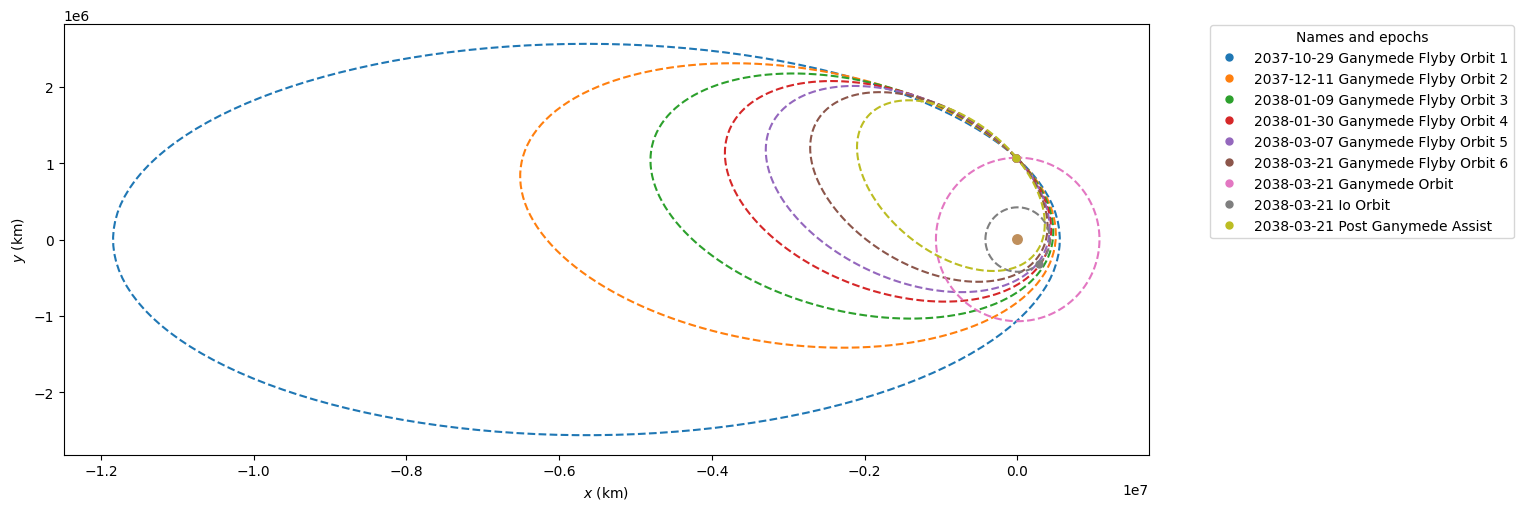

In [106]:
plotter=StaticOrbitPlotter(plane=Planes.EARTH_ECLIPTIC)
for i,orb in enumerate(orbits_post_io):
    all_orbits.append(orb)
    plotter.plot(orb, label=f"Ganymede Flyby Orbit {i+1}")
# plotter.plot(callisto_orb, label="Callisto Orbit")

print((orbits_post_io[-1].r_a/Jupiter.R).to(u.one))
print((orbits_post_io[-1].r_p/Jupiter.R).to(u.one))

search_for_ganymede_1_date=orbits_post_io[-1].epoch
starship_post_io=orbits_post_io[-1]
print(search_for_ganymede_1_date)
plotter.plot(ganymede_orb.propagate(search_for_ganymede_1_date), label="Ganymede Orbit")
plotter.plot(io_orb.propagate(search_for_ganymede_1_date), label="Io Orbit")

starship_post_ganymede_1=ecliptic_slingshot(starship_post_io,ganymede_orb.propagate(search_for_ganymede_1_date),Ganymede,50*u.km,-1)[1]
plotter.plot(starship_post_ganymede_1, label="Post Ganymede Assist")

In [107]:
print(orbits_post_io[-1].ecc)
print(orbits_post_io[-1].a)
print(orbits_post_io[-1].inc)
print(orbits_post_io[-1].epoch)
print(orbits_post_io[-1].raan)
print(orbits_post_io[-1].argp)
print(orbits_post_io[-1].nu)

0.7938696998434569
1699287.7377463453 km
0.04063219314682031 rad
2038-03-21 15:50:06.309
5.907766219727356 rad
2.6171808930868554 rad
2.118874388068257 rad


In [108]:
# #Burn to encounter Callisto
transfer_to_callisto_1=get_single_burn_elliptical_hohmann_brute_force(
    callisto_orb.propagate(search_for_ganymede_1_date),
    starship_post_ganymede_1,
    max_depature_wait=65*u.day,
    tof_step=0.5*u.day,
    min_tof=1*u.day,
    max_tof=75*u.day,
    retrograde_only=False,
    max_encounter_v=8*u.km/u.s,
    fine_scan=False
)


Best dv: 325.1871338630324 m / s
Refining search around burn at 31.5 d with 21.0 d transfer time.
Best dv: 299.69300339781336 m / s


Arrival velocity at Callisto is 5.51 km / s


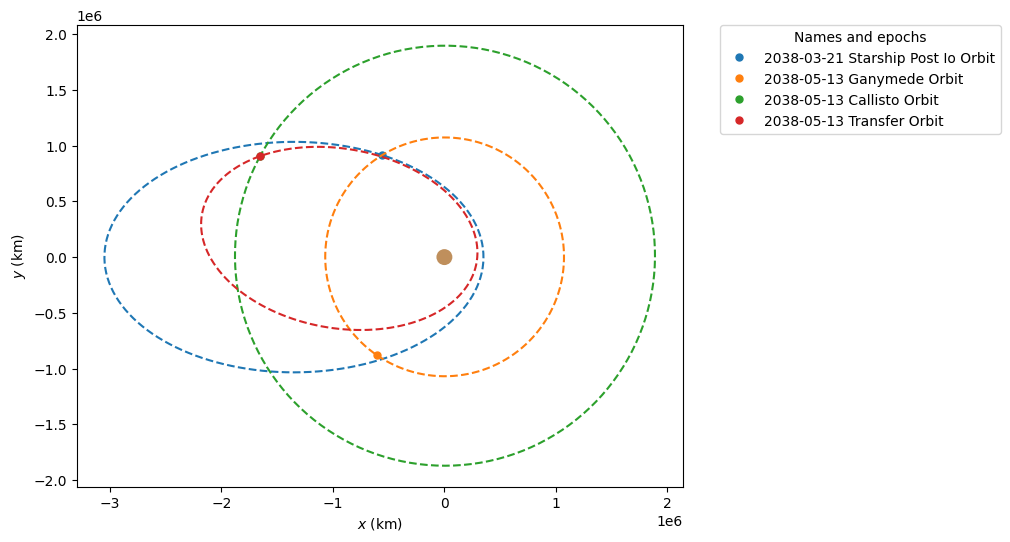

In [109]:
plotter = StaticOrbitPlotter(plane=Planes.EARTH_ECLIPTIC)
plotter.plot(starship_post_io, label="Starship Post Io Orbit")
plotter.plot(ganymede_orb.propagate(transfer_to_callisto_1[3]), label="Ganymede Orbit")
plotter.plot(callisto_orb.propagate(transfer_to_callisto_1[3]), label="Callisto Orbit")
plotter.plot(transfer_to_callisto_1[1].propagate(transfer_to_callisto_1[3]), label="Transfer Orbit")
all_orbits.append(transfer_to_callisto_1[1])
print(f"Arrival velocity at Callisto is {np.linalg.norm(transfer_to_callisto_1[1].propagate(transfer_to_callisto_1[3]).v - callisto_orb.propagate(transfer_to_callisto_1[3]).v):.2f}")
ganymede_arrival_1_date=transfer_to_callisto_1[3]
ganymede_starship_flyby_1=transfer_to_callisto_1[1].propagate(transfer_to_callisto_1[3])

In [110]:
orbits_post_callisto_1=multiple_resonances(ganymede_starship_flyby_1,Callisto,4,lower=False,date_1=start_date,max_num=20)

Flyby 1
Going for [3 5] resonance with periapsis at 1996.4172834566912 km, time till next encounter is 50.08 d
Flyby v inf speed is 5.51 km / s
Spacecraft does 4 complete orbits before arriving, Callisto (○) does 2.
Arrives with distance of 510.73 km
Orbit params post flyby are (<Quantity 5.02212289>, <Quantity 32.45289284>)
Flyby 2
Going for [2 3] resonance with periapsis at 2641.7533506701343 km, time till next encounter is 33.39 d
Flyby v inf speed is 5.51 km / s
Spacecraft does 2 complete orbits before arriving, Callisto (○) does 1.
Arrives with distance of 302.78 km
Orbit params post flyby are (<Quantity 6.00642304>, <Quantity 34.19558656>)
Flyby 3
Going for [3 4] resonance with periapsis at 2779.005801160232 km, time till next encounter is 50.08 d
Flyby v inf speed is 5.51 km / s
Spacecraft does 3 complete orbits before arriving, Callisto (○) does 2.
Arrives with distance of 339.76 km
Orbit params post flyby are (<Quantity 7.12871974>, <Quantity 36.35741295>)
Flyby 4
Going for [1

Final orbit has apojove at 42.85 Rj and perijove at 9.83 Rj


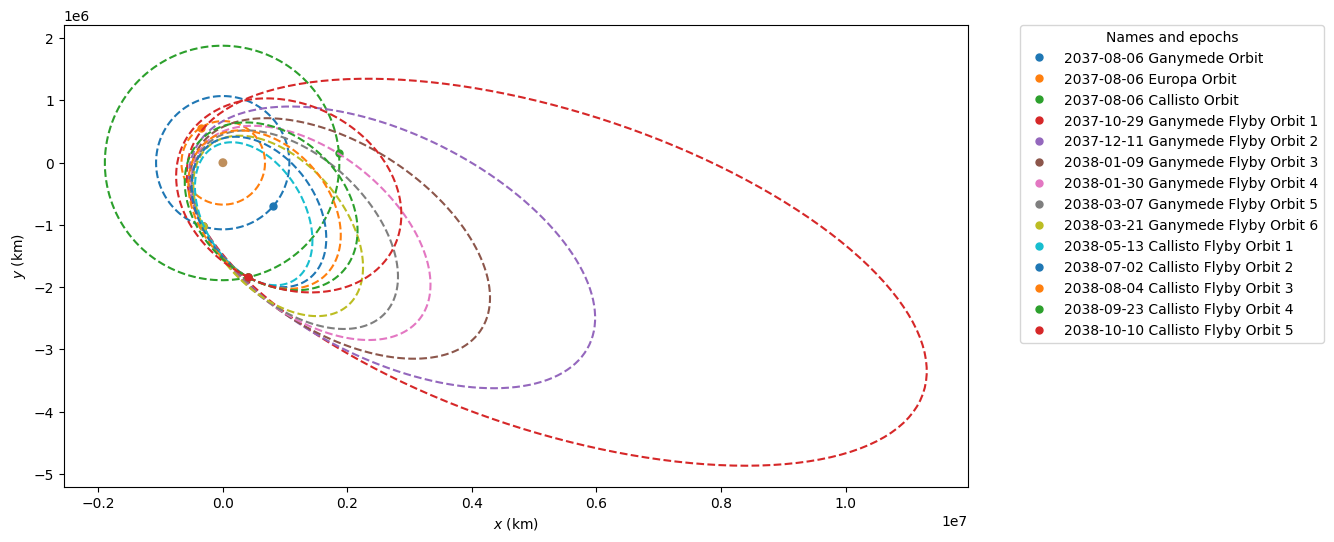

In [111]:

plotter = StaticOrbitPlotter(plane=Planes.EARTH_ECLIPTIC)  
# plotter.plot(pre_io_starship_flyby, label="Pre Io Flyby Orbit")
plotter.plot(ganymede_orb, label="Ganymede Orbit")
plotter.plot(europa_orb, label="Europa Orbit")
plotter.plot(callisto_orb, label="Callisto Orbit")

for i, orb in enumerate(orbits_post_io):
    plotter.plot(orb, label=f"Ganymede Flyby Orbit {i+1}")

for i, orb in enumerate(orbits_post_callisto_1):
    plotter.plot(orb, label=f"Callisto Flyby Orbit {i+1}")
    all_orbits.append(orb)

print(f"Final orbit has apojove at {(orbits_post_callisto_1[-1].r_a/Jupiter.R).to(u.one):.2f} Rj and perijove at {(orbits_post_callisto_1[-1].r_p/Jupiter.R).to(u.one):.2f} Rj" )
starship_post_callisto_1=orbits_post_callisto_1[-1].propagate(orbits_post_callisto_1[-2].epoch)

In [112]:
callisto_to_europa_1=get_single_burn_elliptical_hohmann_brute_force(
    europa_orb.propagate(starship_post_callisto_1.epoch),
    starship_post_callisto_1,
    min_departure_wait=0*u.day,
    max_depature_wait=55*u.day,
    tof_step=0.5*u.day,
    min_tof=1*u.day,
    max_tof=32*u.day,
    retrograde_only=False,
    max_encounter_v=5.5*u.km/u.s,   
    fine_scan=False
)

Best dv: 181.4962107465292 m / s
Refining search around burn at 23.0 d with 7.5 d transfer time.
Best dv: 136.3840278284435 m / s


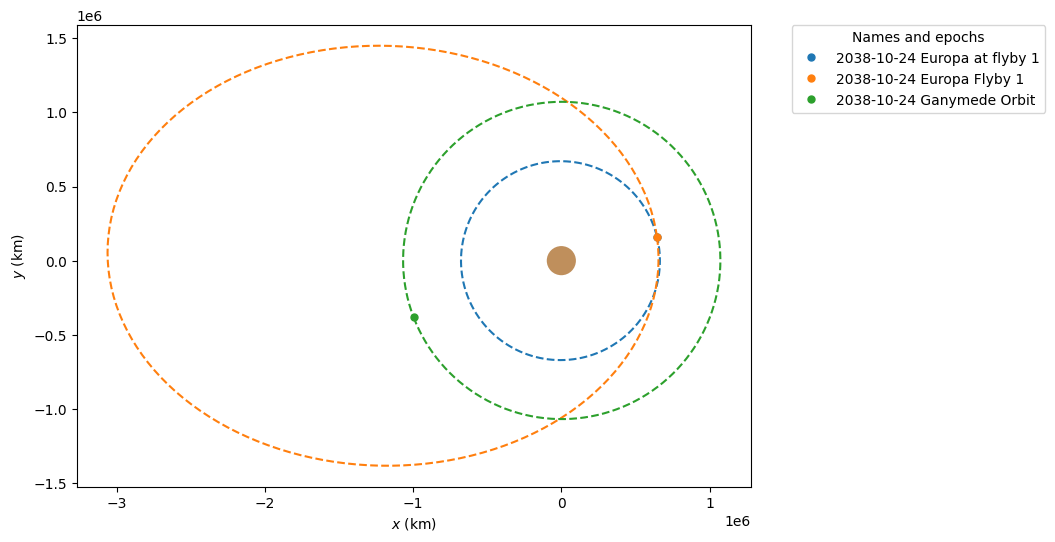

In [113]:
#if g assist doesnt work
plotter = StaticOrbitPlotter(plane=Planes.EARTH_ECLIPTIC)
europa_flyby_1_date=callisto_to_europa_1[3]
europa_flyby_1=callisto_to_europa_1[1].propagate(europa_flyby_1_date)
# plotter.plot(starship_post_ganymede_1, label="Starship Post Ganymede Orbit")
plotter.plot(callisto_to_europa_1[2], label="Europa at flyby 1")
plotter.plot(europa_flyby_1, label="Europa Flyby 1")
# all_orbits.append(europa_flyby_1)
plotter.plot(ganymede_orb.propagate(europa_flyby_1_date), label="Ganymede Orbit")

In [114]:
print(f"First Europa flyby {europa_flyby_1_date-start_date} after start of simulation.")

First Europa flyby 444.36224238654927 after start of simulation.


In [115]:
#asuming gravity assist above works, commented for now

# plotter = StaticOrbitPlotter(plane=Plansst[1].epoch
# europa_flyby_1=ganymede_europa_assist[0].propagate(europa_flyby_1_date)
# # plotter.plot(starship_post_ganymede_1, label="Starship Post Ganymede Orbit")
# plotter.plot(ganymede_europa_assist[1], label="Europa at flyby 1")
# plotter.plot(europa_flyby_1, label="Europa Flyby 1")
# all_orbits.append(europa_flyby_1)
# plotter.plot(ganymede_orb.propagate(europa_flyby_1_date), label="Ganymede Orbit")

In [120]:
orbits_post_europa_1=multiple_resonances(europa_flyby_1,Europa,8,lower=True,date_1=start_date)

Flyby 1
Going for [4 1] resonance with periapsis at 1367.5515103020605 km, time till next encounter is 14.21 d
Flyby v inf speed is 4.18 km / s
Spacecraft does 0 complete orbits before arriving, Europa (☾) does 3.
Arrives with distance of 161.02 km
Orbit params post flyby are (<Quantity 9.09000236>, <Quantity 38.21433362>)
Flyby 2
Going for [7 2] resonance with periapsis at 1838.2026405281056 km, time till next encounter is 24.86 d
Flyby v inf speed is 4.18 km / s
Spacecraft does 1 complete orbits before arriving, Europa (☾) does 6.
Arrives with distance of 225.68 km
Orbit params post flyby are (<Quantity 9.00387611>, <Quantity 34.2713395>)
Flyby 3
Going for [3 1] resonance with periapsis at 1474.3588717743548 km, time till next encounter is 10.65 d
Flyby v inf speed is 4.18 km / s
Spacecraft does 0 complete orbits before arriving, Europa (☾) does 2.
Arrives with distance of 19.85 km
Orbit params post flyby are (<Quantity 8.88752172>, <Quantity 30.16118498>)
Flyby 4
Going for [5 2] res

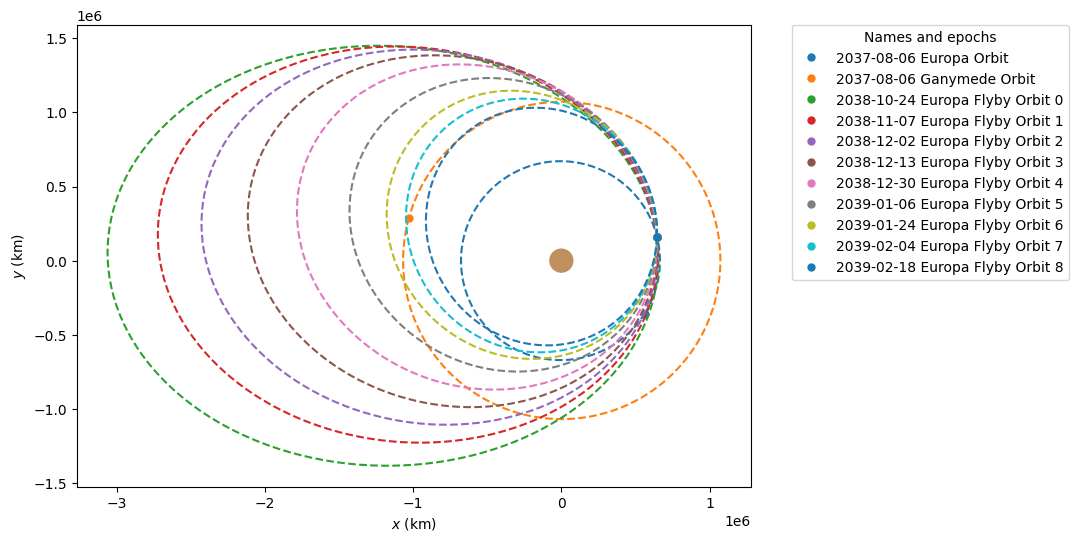

In [121]:
plotter = StaticOrbitPlotter(plane=Planes.EARTH_ECLIPTIC)
plotter.plot(europa_orb, label="Europa Orbit")
plotter.plot(ganymede_orb, label="Ganymede Orbit")
for orb in orbits_post_europa_1:
    plotter.plot(orb, label=f"Europa Flyby Orbit {orbits_post_europa_1.index(orb)}")
# plotter.plot(orbits_post_europa_1[-1], label="Europa Flyby Orbit 1")

In [122]:
pre_burn_to_ganymede_2=orbits_post_europa_1[-1].propagate(orbits_post_europa_1[-2].epoch)
#repace w -1 and -2 

europa_to_ganymede_2=get_single_burn_elliptical_hohmann_brute_force(
    ganymede_orb.propagate(pre_burn_to_ganymede_2.epoch),
    pre_burn_to_ganymede_2,
    max_depature_wait=25*u.day,
    tof_step=0.4*u.day,
    min_tof=1*u.day,
    max_tof=45*u.day,
    retrograde_only=True,
    max_encounter_v=5*u.km/u.s,
    fine_scan=False
)



Best dv: 572.8666677994743 m / s
Refining search around burn at 5.2 d with 11.4 d transfer time.
Best dv: 412.8367198313369 m / s


In [ ]:
final_ganymede_date=europa_to_ganymede_2[3]
final_ganymede_orb=europa_to_ganymede_2[1].propagate(final_ganymede_date)
ganymede_at_fly=europa_to_ganymede_2[2]

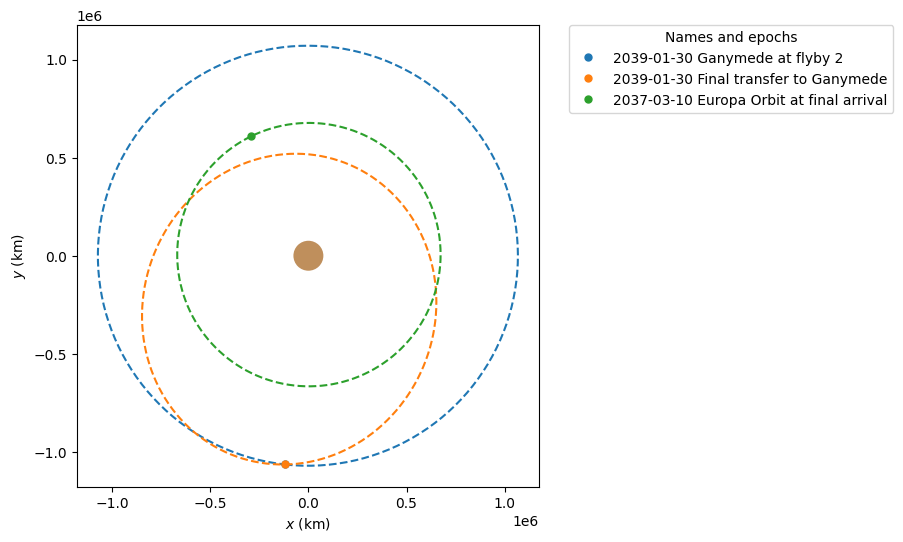

In [ ]:
# final_ganymede_date=assist_to_ganymede_2[1].epoch
# final_ganymede_flyby_orb=assist_to_ganymede_2[0].propagate(final_ganymede_date)

plotter=StaticOrbitPlotter(plane=Planes.EARTH_ECLIPTIC)

# for i,orb in enumerate(orbits_post_europa_1):     
#     plotter.plot(orb, label=f"Europa Flyby Orbit {i}")
#     all_orbits.append(orb)
# plotter.plot(ganymede_orb, label="Ganymede Orbit")
# plotter.plot(final_ganymede_flyby_orb, label="Ganymede Flyby 2")
plotter.plot(ganymede_at_fly, label="Ganymede at flyby 2")
plotter.plot(final_ganymede_orb, label="Final transfer to Ganymede")

plotter.plot(europa_orb, label="Europa Orbit at final arrival")


In [ ]:
starship_post_ganymede_2=ecliptic_slingshot(final_ganymede_orb,ganymede_at_fly,Ganymede,2200*u.km,-1)[-1]

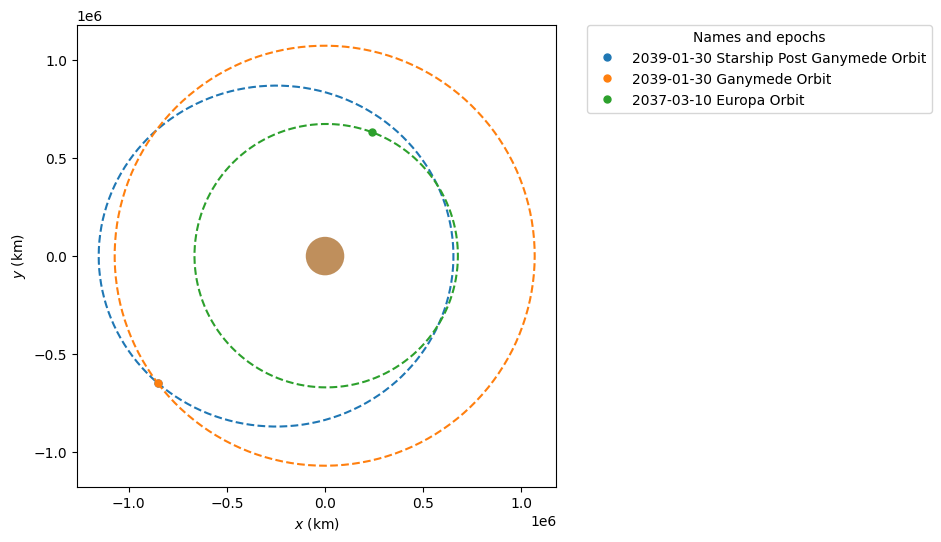

In [ ]:
plotter = StaticOrbitPlotter(plane=Planes.EARTH_ECLIPTIC)
plotter.plot(starship_post_ganymede_2, label="Starship Post Ganymede Orbit")
plotter.plot(ganymede_orb.propagate(final_ganymede_date), label="Ganymede Orbit")
plotter.plot(europa_orb, label="Europa Orbit")

In [ ]:
final_transfer_to_europa=get_single_burn_elliptical_hohmann_brute_force(
    europa_orb.propagate(final_ganymede_date),
    starship_post_ganymede_2,
    max_depature_wait=35*u.day,
    tof_step=0.5*u.day,
    min_tof=1*u.day,
    max_tof=40*u.day,
    retrograde_only=True,
    max_encounter_v=2.0*u.km/u.s,
    fine_scan=False
)

Best dv: 168.836925845384 m / s
Refining search around burn at 22.5 d with 13.0 d transfer time.
Best dv: 150.84234484238334 m / s


Arrival velocity at Europa is 1.89 km / s
Took 727.4 d to reach Europa after entering Jovian system


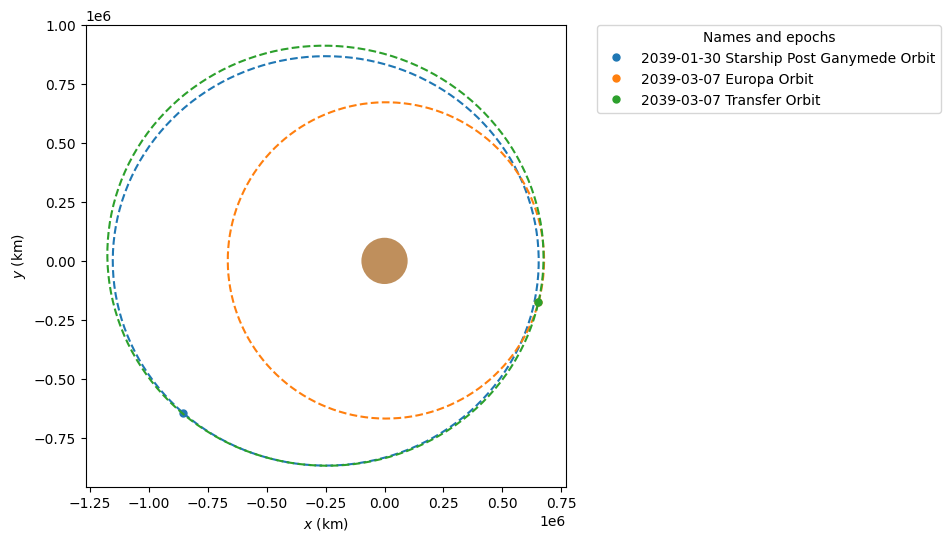

In [ ]:

plotter=StaticOrbitPlotter(plane=Planes.EARTH_ECLIPTIC)
all_orbits.append(final_transfer_to_europa[1])
final_europa_orb=europa_orb.propagate(final_transfer_to_europa[3])
plotter.plot(starship_post_ganymede_2, label="Starship Post Ganymede Orbit")
plotter.plot(final_europa_orb, label="Europa Orbit")
plotter.plot(final_transfer_to_europa[1].propagate(final_transfer_to_europa[3]), label="Transfer Orbit")
final_arrival_speed=np.linalg.norm(final_transfer_to_europa[1].propagate(final_transfer_to_europa[3]).v-final_europa_orb.v)
print(f"Arrival velocity at Europa is {final_arrival_speed:.2f}")
final_arrival_date=final_transfer_to_europa[3]
jovian_system_time=(final_arrival_date-start_date).to(u.day)
print(f"Took {jovian_system_time:.1f} to reach Europa after entering Jovian system")

11796180 x 75067 km x 2.2 deg orbit around Jupiter (♃) at epoch 2037-02-18 00:02:09.185 (TDB)
11796180 x 75067 km x 2.2 deg orbit around Jupiter (♃) at epoch 2037-03-30 00:02:09.185 (TDB)
453983 x 11835121 km x 2.3 deg orbit around Jupiter (♃) at epoch 2037-04-02 20:26:09.185 (TDB)
453983 x 11835121 km x 2.3 deg orbit around Jupiter (♃) at epoch 2037-06-01 12:02:09.185 (TDB)
412171 x 7420909 km x 2.3 deg orbit around Jupiter (♃) at epoch 2037-07-21 13:50:15.921 (TDB)
384262 x 5874947 km x 2.3 deg orbit around Jupiter (♃) at epoch 2037-08-26 08:16:03.589 (TDB)
361328 x 5032729 km x 2.3 deg orbit around Jupiter (♃) at epoch 2037-09-23 23:00:41.724 (TDB)
326206 x 4126525 km x 2.3 deg orbit around Jupiter (♃) at epoch 2037-10-15 10:04:10.324 (TDB)
300473 x 3642589 km x 2.3 deg orbit around Jupiter (♃) at epoch 2037-11-20 04:29:57.993 (TDB)
331359 x 3740237 km x 2.0 deg orbit around Jupiter (♃) at epoch 2038-01-09 06:53:57.993 (TDB)
331359 x 3740237 km x 2.0 deg orbit around Jupiter (♃) at 

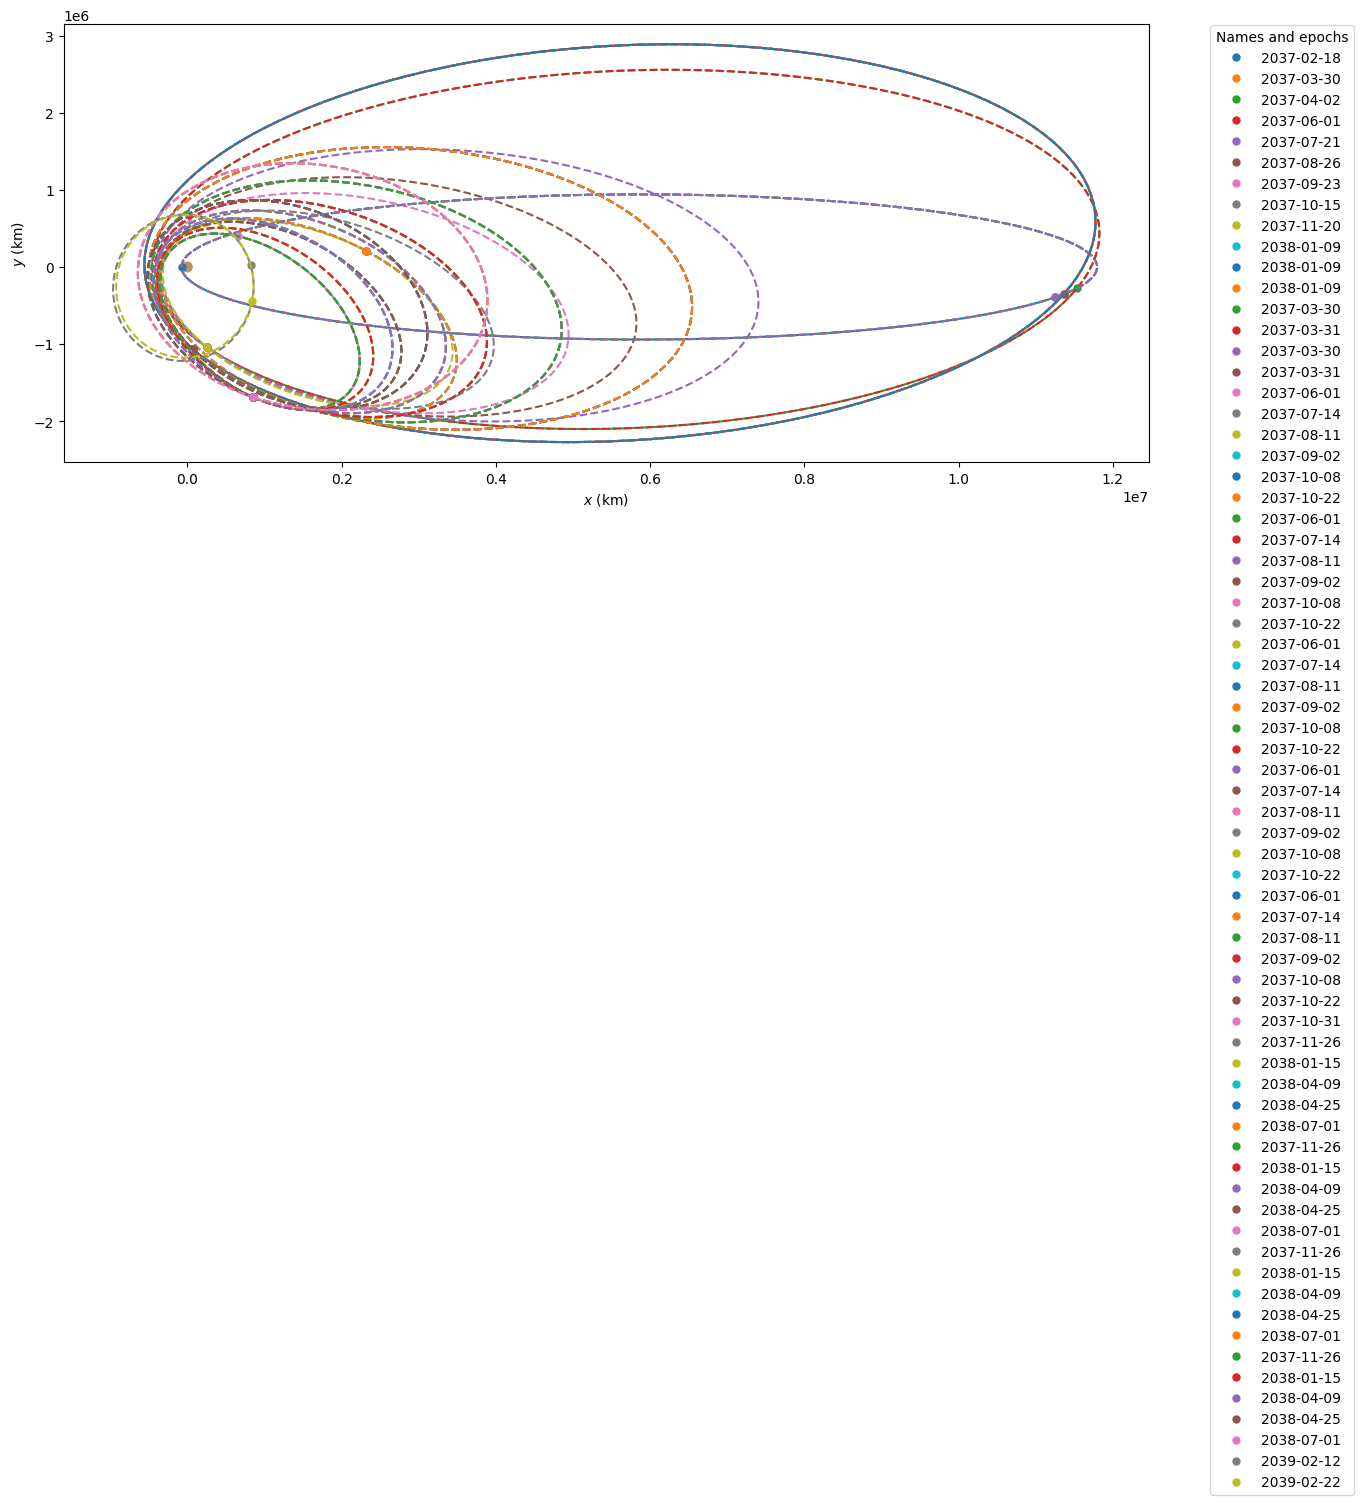

In [ ]:
plotter=StaticOrbitPlotter(plane=Planes.EARTH_ECLIPTIC)
for orbs in all_orbits:
    plotter.plot(orbs)
    print(orbs)
    

In [ ]:
model = jovian_spenvis_model.build_fast_e_p_spectrum_lookup("tests/spenvis_files/spenvis_spe.txt", "tests/spenvis_files/spenvis_spp.txt")

def tid_for_orbit(orbit,start,end,step=0.1*u.day):
    cum_tid=0
    flux=[]
    times=[]
    periods=int(((end-start).to(u.day)/step).value)
    for t in (time_range(start=start,end=end,periods=periods)):
        test_orb=orbit.propagate(t)
        r=((np.linalg.norm(test_orb.r))/Jupiter.R).to(u.one)
        # print(r)
        inst_flux=jovian_spenvis_model.electron_flux_gt2MeV(r,model)
        flux.append(inst_flux)
        times.append((t-start).to(u.hour).value)
        cum_tid+=inst_flux
        
    return cum_tid,flux,times
    

In [ ]:
#loop through all orbs and add fluxes up
total_flux=0
all_fluxes=[]
all_times=[]
iterated_shift_time=0

for i,orb in enumerate(all_orbits):
    temp_start=orb.epoch
    temp_end=None
    if i==len(all_orbits)-1:
        temp_end=final_arrival_date
    else:
        temp_end=all_orbits[i+1].epoch
    orbital_flux_info=tid_for_orbit(orb,temp_start,temp_end)
    total_flux+=orbital_flux_info[0]
    all_fluxes += (orbital_flux_info[1])
    all_times += (orbital_flux_info[2])
    iterated_shift_time=all_times



Text(0.5, 0, 'Time since Jovian system entry (days)')

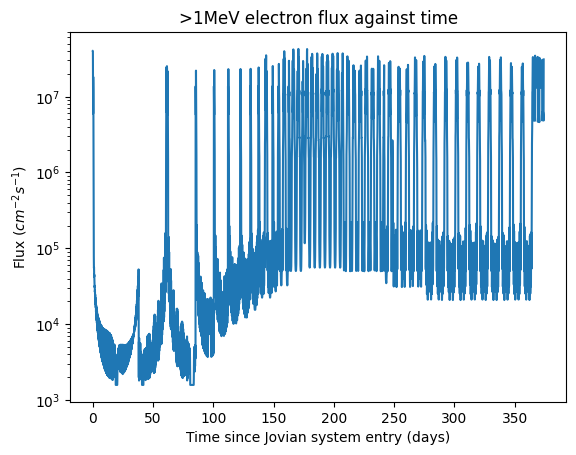

In [ ]:
# print(all_times)
test_x=np.linspace(0,jovian_system_time,len(all_fluxes))
plt.semilogy(test_x,all_fluxes)  
plt.title(">1MeV electron flux against time")
plt.ylabel("Flux ($cm^{-2}s^{-1}$)")
plt.xlabel("Time since Jovian system entry (days)")

/home/jack/Documents/miniforge3-n/envs/cleanastronomy/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning:

ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"

/home/jack/Documents/miniforge3-n/envs/cleanastronomy/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning:

ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"

/home/jack/Documents/miniforge3-n/envs/cleanastronomy/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning:

ERFA function "utctai" yielded 1 of "dubious year (Note 3)"

/home/jack/Documents/miniforge3-n/envs/cleanastronomy/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning:

ERFA function "taiutc" yielded 150 of "dubious year (Note 4)"



Arrival speed (at periapsis) is 2.7474862294609825 km / s
EOI burn with 1.34 km / s delta-V.
Final orbit velocity is 1.4100674772998854 km / s


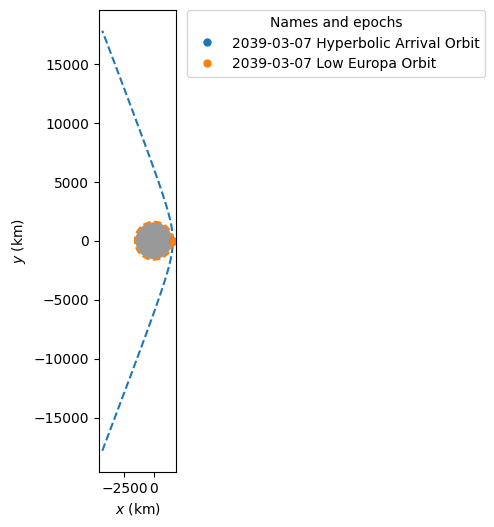

In [ ]:
# v_sc_arriv = final_arrival_speed
v_sc_arriv=1.89*u.km/u.s
body1=Europa
c3_a = np.linalg.norm(v_sc_arriv)**2

#C3 only orbit calc
r_p = 50*u.km#arrival periapsis
a_exit = -(body1.k / c3_a).to(u.km)
ecc_exit = 1 - (r_p+body1.R) / a_exit
end_date = final_arrival_date

arrival_orbit = Orbit.from_classical(
    body1,
    a_exit,
    ecc_exit,
    0 * u.deg,
    0 * u.deg,
    0 * u.deg,
    0 * u.deg,  # We don't mind
    time.Time(end_date, scale="utc"),
)
arrival_circular_orbit = Orbit.circular(body1,alt = r_p, epoch=time.Time(end_date, scale="utc"))
EOI_DV = np.linalg.norm(arrival_orbit.v)-np.linalg.norm(arrival_circular_orbit.v)

print(f"Arrival speed (at periapsis) is {np.linalg.norm(arrival_orbit.v)}")
print(f"EOI burn with {EOI_DV:.2f} delta-V.")
print(f"Final orbit velocity is {np.linalg.norm(arrival_circular_orbit.v)}")


plotter = StaticOrbitPlotter()

plotter.plot(arrival_orbit, label="Hyperbolic Arrival Orbit")
plotter.plot(arrival_circular_orbit, label="Low Europa Orbit")